## Project: Manchu-English Translation, Attempt 3: encoder-decoder model using mBART

In [2]:
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.2 MB/s eta 0:00:00


In [3]:
BASE_DIR = '/content/drive/MyDrive/2025nn'

# Attempt 3: manchuBERT + mBART

In [33]:
import os
import json
import time
import math
import random
import matplotlib.pyplot as plt

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    EncoderDecoderModel,
    MBart50TokenizerFast,
    set_seed
)

from sacrebleu import corpus_bleu


In [40]:
SEED = 6600
set_seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

fpath = "/content/drive/MyDrive/2025nn/parallel.csv"
val_fpath = "/content/drive/MyDrive/2025nn/cathay-validation.csv"
src_col = "manchu"
tgt_col = "english"

output_fpath = "./runs/attempt3"
os.makedirs(output_fpath, exist_ok=True)

MAX_SRC_LEN = 128
MAX_TGT_LEN = 128
BATCH_SIZE = 8
EPOCHS = 30
LR = 3e-5

SRC_MODEL = "seemdog/manchuBERT"
MBART_MODEL = "facebook/mbart-large-50-many-to-many-mmt"
TGT_LANG_CODE = "en_XX"     # generated English

### Prepare Data

In [35]:
def load_splits():
    df = pd.read_csv(fpath)
    src_all = tuple(df[src_col].astype(str))
    tgt_all = tuple(df[tgt_col].astype(str))

    train_src, test_src, train_tgt, test_tgt = train_test_split(
        src_all, tgt_all, test_size=0.25, random_state=SEED
    )
    val_src, test_src, val_tgt, test_tgt = train_test_split(
        test_src, test_tgt, test_size=0.5, random_state=SEED
    )

    # val_df = pd.read_csv(val_fpath)
    # val_src = tuple(val_df[src_col].astype(str))
    # val_tgt = tuple(val_df[tgt_col].astype(str))

    return train_src, train_tgt, val_src, val_tgt, test_src, test_tgt


In [36]:
class PairDataset(Dataset):
    def __init__(self, src, tgt):
        self.src = list(src)
        self.tgt = list(tgt)

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return self.src[idx], self.tgt[idx]


def collate_fn(batch, src_tok, tgt_tok):
    src_texts, tgt_texts = zip(*batch)

    src_enc = src_tok(
        list(src_texts),
        padding=True,
        truncation=True,
        max_length=MAX_SRC_LEN,
        return_tensors="pt",
        return_token_type_ids=False,
    )

    tgt_enc = tgt_tok(
        list(tgt_texts),
        padding=True,
        truncation=True,
        max_length=MAX_TGT_LEN,
        return_tensors="pt",
    )

    labels = tgt_enc["input_ids"].clone()
    labels[labels == tgt_tok.pad_token_id] = -100

    return {
        "input_ids": src_enc["input_ids"],
        "attention_mask": src_enc["attention_mask"],
        "labels": labels,
    }

### Place Model

reference:

- https://huggingface.co/docs/transformers/en/model_doc/encoder-decoder


In [37]:
def build_model():
    model = EncoderDecoderModel.from_encoder_decoder_pretrained(
        SRC_MODEL,
        MBART_MODEL
    )
    # tokenization
    src_tok = AutoTokenizer.from_pretrained(SRC_MODEL)
    tgt_tok = MBart50TokenizerFast.from_pretrained(MBART_MODEL)

    model.config.decoder_start_token_id = tgt_tok.lang_code_to_id[TGT_LANG_CODE]
    model.config.eos_token_id = tgt_tok.eos_token_id
    model.config.pad_token_id = tgt_tok.pad_token_id
    model.config.vocab_size = model.decoder.config.vocab_size

    return model, src_tok, tgt_tok

### Training

In [38]:
def train_epoch(model, loader, optimizer):
    model.train()
    total = 0.0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        loss = out.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item()
    return total / len(loader)

### Helper functions

In [39]:
@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total = 0.0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        total += out.loss.item()
    return total / len(loader)


@torch.no_grad()
def generate_batch(model, src_texts, src_tok, tgt_tok, num_beams=5):
    model.eval()
    preds = []
    for s in src_texts:
        enc = src_tok(
            s,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_SRC_LEN,
            return_token_type_ids=False,
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        gen = model.generate(
            **enc,
            forced_bos_token_id=tgt_tok.lang_code_to_id[TGT_LANG_CODE],
            num_beams=num_beams,
            max_length=MAX_TGT_LEN,
            early_stopping=True,
            repetition_penalty=1.2,
            length_penalty=1.0,
        )
        preds.append(tgt_tok.batch_decode(gen, skip_special_tokens=True)[0])
    return preds


def compute_bleu(preds, refs):
    return corpus_bleu(preds, [refs]).score


def pretty_samples(src, ref, hyp, k=8):
    out = []
    for i in range(min(k, len(src))):
        out.append(
            f"SRC: {src[i]}\n"
            f"REF: {ref[i]}\n"
            f"GEN: {hyp[i]}\n"
            + "-" * 60
        )
    return "\n".join(out)


### Main

Some weights of BertModel were not initialized from the model checkpoint at seemdog/manchuBERT and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

Some weights of MBartForCausalLM were not initialized from the model checkpoint at facebook/mbart-large-50-many-to-many-mmt and are newly initialized: ['lm_head.weight', 'model.decoder.embed_tokens.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:555: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  decoder_attention_mask = decoder_input_ids.new_tensor(decoder_input_ids != self.config.pad_token_id)
/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:575: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Epoch 01 | Train 9.589 | Val 8.126 | BLEU 0.000 ✓loss ✓bleu
Epoch 02 | Train 6.771 | Val 6.947 | BLEU 0.154 ✓loss ✓bleu
Epoch 03 | Train 5.315 | Val 6.759 | BLEU 0.204 ✓loss ✓bleu
Epoch 04 | Train 4.324 | Val 6.700 | BLEU 0.445 ✓loss ✓bleu
Epoch 05 | Train 3.552 | Val 6.859 | BLEU 0.030  
Epoch 06 | Train 3.077 | Val 7.164 | BLEU 0.018  
Epoch 07 | Train 2.745 | Val 6.890 | BLEU 0.262  
Epoch 08 | Train 2.403 | Val 7.375 | BLEU 0.027  
Epoch 09 | Train 2.195 | Val 7.286 | BLEU 0.012  
Epoch 10 | Train 1.996 | Val 7.583 | BLEU 0.326  
Epoch 11 | Train 1.871 | Val 7.271 | BLEU 0.247  
Epoch 12 | Train 1.617 | Val 7.367 | BLEU 0.253  
Epoch 13 | Train 1.333 | Val 7.410 | BLEU 0.563  ✓bleu
Epoch 14 | Train 1.224 | Val 7.829 | BLEU 0.032  
Epoch 15 | Train 0.952 | Val 7.518 | BLEU 0.546  
Epoch 16 | Train 0.807 | Val 7.572 | BLEU 0.682  ✓bleu
Epoch 17 | Train 0.718 | Val 7.822 | BLEU 0.244  
Epoch 18 | Train 0.598 | Val 7.729 | BLEU 0.743  ✓bleu
Epoch 19 | Train 0.454 | Val 8.021 | BLEU 0.6

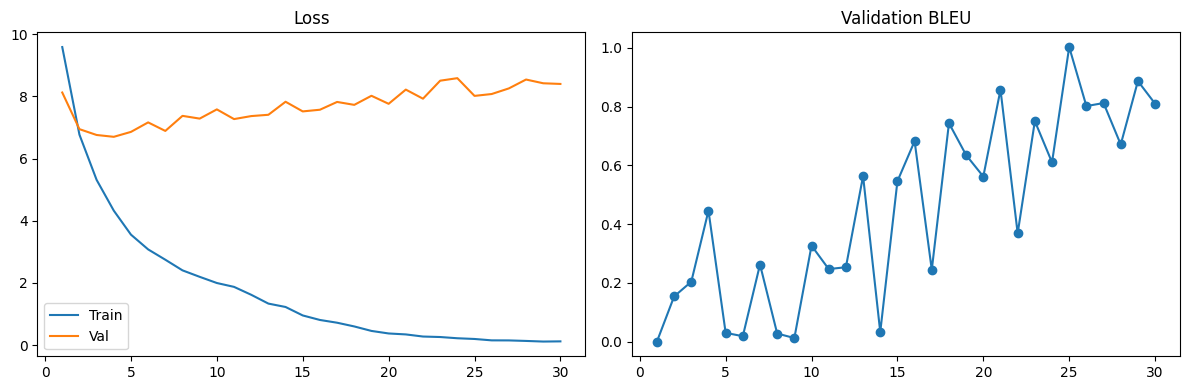


=== TEST (best_val_loss) ===
BLEU: 0.4651905829539645
SRC: manggai amba tacin i bithe dabala
REF: it is the great learning
GEN: is is is
------------------------------------------------------------
SRC: bi umai seme gisurehekv
REF: i was not saying anything
GEN: i
------------------------------------------------------------
SRC: doron be waliyabuci ja baita
REF: the loss of a seal is an ordinary occurrence after all
GEN: not not not not not not not
------------------------------------------------------------
SRC: xi halai nun simbe aliyame tehebi
REF: cousin shih is waiting for you
GEN: i i
------------------------------------------------------------
SRC: jiduji loo tai tai fulu kai
REF: your venerable ladyship
GEN: is is is is
------------------------------------------------------------
SRC: yafan i dergi amargi hoxoi bade
REF: supply of pine and cedar trees in the northeast corner of the park
GEN: is is is
------------------------------------------------------------
SRC: hvdun jefu


In [ ]:
def main():
    train_src, train_tgt, val_src, val_tgt, test_src, test_tgt = load_splits()

    model, src_tok, tgt_tok = build_model()
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    train_loader = DataLoader(
        PairDataset(train_src, train_tgt),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=lambda b: collate_fn(b, src_tok, tgt_tok),
    )
    val_loader = DataLoader(
        PairDataset(val_src, val_tgt),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=lambda b: collate_fn(b, src_tok, tgt_tok),
    )

    history = []
    best_val_loss = float("inf")
    best_val_bleu = -1.0

    for epoch in range(1, EPOCHS + 1):
        tr = train_epoch(model, train_loader, optimizer)
        vl = eval_loss(model, val_loader)

        preds = generate_batch(model, val_src, src_tok, tgt_tok)
        vb = compute_bleu(preds, list(val_tgt))

        history.append(dict(epoch=epoch, train_loss=tr, val_loss=vl, val_bleu=vb))

        if vl <= best_val_loss:
            best_val_loss = vl
            torch.save(model.state_dict(), os.path.join(output_fpath, "best_val_loss.pt"))

        if vb >= best_val_bleu:
            best_val_bleu = vb
            torch.save(model.state_dict(), os.path.join(output_fpath, "best_val_bleu.pt"))

        if epoch == 25:
            torch.save(model.state_dict(), os.path.join(output_fpath, "fitter.pt"))

        loss_mark = "✓loss" if vl <= best_val_loss else ""
        bleu_mark = "✓bleu" if vb >= best_val_bleu else ""

        print(
            f"Epoch {epoch:02d} | "
            f"Train {tr:.3f} | Val {vl:.3f} | BLEU {vb:.3f} "
            f"{loss_mark} {bleu_mark}"
        )

    epochs = [h["epoch"] for h in history]
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, [h["train_loss"] for h in history], label="Train")
    plt.plot(epochs, [h["val_loss"] for h in history], label="Val")
    plt.legend(); plt.title("Loss")

    plt.subplot(1,2,2)
    plt.plot(epochs, [h["val_bleu"] for h in history], marker="o")
    plt.title("Validation BLEU")
    plt.tight_layout()
    plt.savefig(os.path.join(output_fpath, "curves.png"))
    plt.show()

    # three checkpoints
    for tag in ["best_val_loss", "best_val_bleu", 'fitter']:
        print(f"\n=== TEST ({tag}) ===")
        model.load_state_dict(torch.load(os.path.join(output_fpath, f"{tag}.pt")))
        preds = generate_batch(model, test_src, src_tok, tgt_tok)
        bleu = compute_bleu(preds, list(test_tgt))
        print("BLEU:", bleu)
        print(pretty_samples(test_src, test_tgt, preds))


if __name__ == "__main__":
    main()
